# Stereo Depth Estimation — Full Analysis

This notebook covers two subtasks:
- **Subtask 1**: Comparison of stereo matching configurations (window size, disparity, aggregate window)
- **Subtask 2**: Hyperparameter sweep for YOLO + MiDaS depth-based object detection

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
PALETTE = sns.color_palette('Set2')

print('Libraries loaded ✓')

Libraries loaded ✓


In [3]:
# ── Load data ────────────────────────────────────────────────────────────────
s1_metrics  = pd.read_csv('outputs/subtask1_compare_metrics.csv')
s1_summary  = pd.read_csv('outputs/subtask1_compare_summary.csv')
s2_metrics  = pd.read_csv('outputs/subtask2_hyperparam_metrics.csv')
s2_summary  = pd.read_csv('outputs/subtask2_hyperparam_summary.csv')

print('Subtask 1 — per-image metrics:', s1_metrics.shape)
print('Subtask 1 — config summary:    ', s1_summary.shape)
print('Subtask 2 — per-image metrics:', s2_metrics.shape)
print('Subtask 2 — config summary:    ', s2_summary.shape)

Subtask 1 — per-image metrics: (20, 21)
Subtask 1 — config summary:     (5, 14)
Subtask 2 — per-image metrics: (16, 21)
Subtask 2 — config summary:     (4, 17)


---
## Part 1 · Stereo Configuration Comparison

Five configurations are tested across four image pairs.  
Each config is defined by `window_size`, `max_disparity`, and `aggregate_window`.

**Key metrics**: MAE, RMSE, Pearson correlation, and timing breakdown.

In [4]:
# ── 1-A · Summary table ──────────────────────────────────────────────────────
display_cols = [
    'config', 'window_size', 'max_disparity', 'aggregate_window',
    'avg_mae', 'avg_rmse', 'avg_p50_abs_diff', 'avg_p90_abs_diff',
    'avg_corr', 'avg_time_total_s'
]
styled = (
    s1_summary[display_cols]
    .sort_values('avg_mae')
    .reset_index(drop=True)
    .style
    .format({
        'avg_mae': '{:.4f}', 'avg_rmse': '{:.4f}',
        'avg_p50_abs_diff': '{:.4f}', 'avg_p90_abs_diff': '{:.4f}',
        'avg_corr': '{:.4f}', 'avg_time_total_s': '{:.3f} s'
    })
    .background_gradient(subset=['avg_mae', 'avg_rmse'], cmap='RdYlGn_r')
    .background_gradient(subset=['avg_corr'], cmap='RdYlGn')
    .background_gradient(subset=['avg_time_total_s'], cmap='Oranges')
    .set_caption('Table 1 · Summary per stereo config (sorted by MAE ↑ = worse)')
)
display(styled)

,config,window_size,max_disparity,aggregate_window,avg_mae,avg_rmse,avg_p50_abs_diff,avg_p90_abs_diff,avg_corr,avg_time_total_s
0,w7_d96_a9,7,96,9,0.1355,0.2085,0.0848,0.3209,0.6704,6.460 s
1,w7_d64_a11,7,64,11,0.1567,0.2283,0.1089,0.3600,0.6610,4.692 s
2,w7_d64_a9,7,64,9,0.1622,0.2359,0.1110,0.3886,0.6360,5.792 s
3,w5_d64_a9,5,64,9,0.1672,0.2426,0.1126,0.4126,0.6094,4.444 s
4,w5_d48_a7,5,48,7,0.2509,0.3126,0.2101,0.5209,0.3827,5.206 s


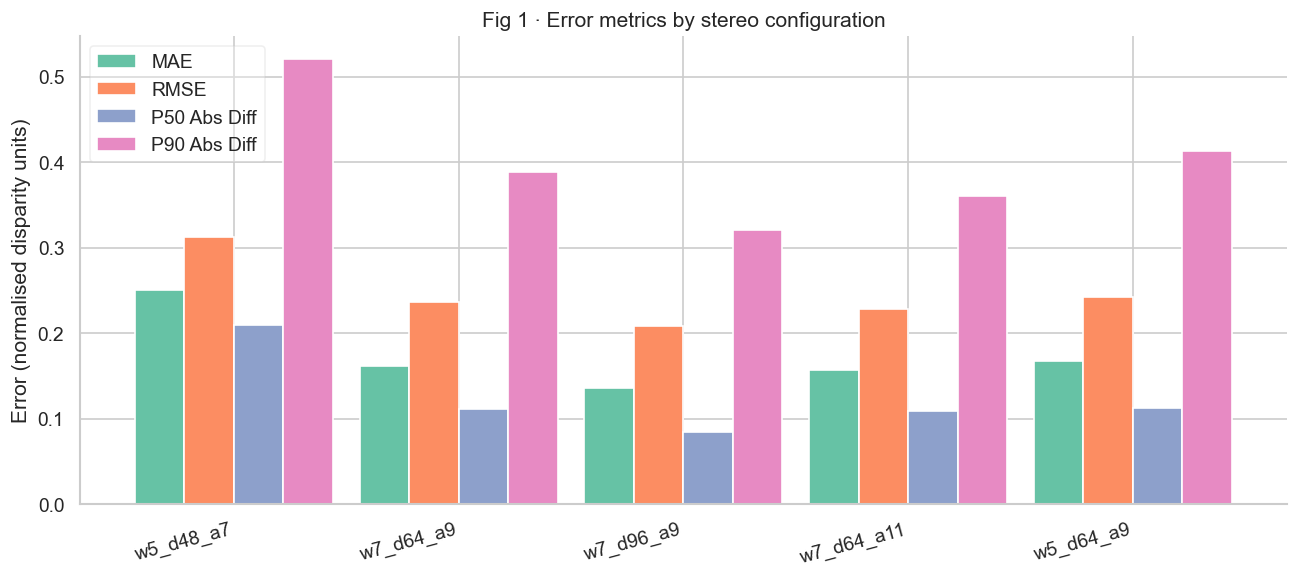

In [5]:
# ── 1-B · Error metrics bar chart ────────────────────────────────────────────
configs = s1_summary['config'].tolist()
x = np.arange(len(configs))
w = 0.22

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w*1.5, s1_summary['avg_mae'],          w, label='MAE',          color=PALETTE[0])
ax.bar(x - w*0.5, s1_summary['avg_rmse'],         w, label='RMSE',         color=PALETTE[1])
ax.bar(x + w*0.5, s1_summary['avg_p50_abs_diff'], w, label='P50 Abs Diff', color=PALETTE[2])
ax.bar(x + w*1.5, s1_summary['avg_p90_abs_diff'], w, label='P90 Abs Diff', color=PALETTE[3])

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15, ha='right')
ax.set_ylabel('Error (normalised disparity units)')
ax.set_title('Fig 1 · Error metrics by stereo configuration')
ax.legend(framealpha=0.3)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

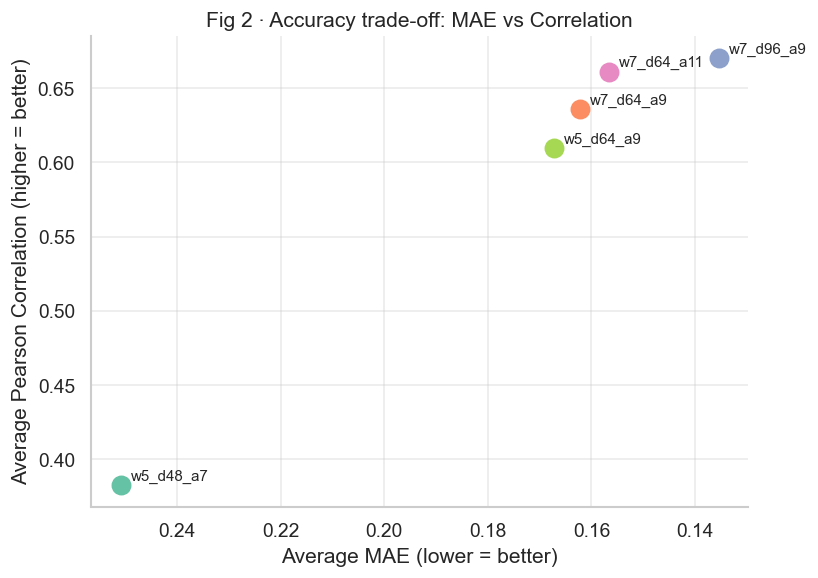

Note: ideal config is top-left (low MAE, high correlation).


In [6]:
# ── 1-C · Correlation vs MAE scatter (trade-off view) ────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for i, row in s1_summary.iterrows():
    ax.scatter(row['avg_mae'], row['avg_corr'], s=120, color=PALETTE[i], zorder=3)
    ax.annotate(row['config'], (row['avg_mae'], row['avg_corr']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.set_xlabel('Average MAE (lower = better)')
ax.set_ylabel('Average Pearson Correlation (higher = better)')
ax.set_title('Fig 2 · Accuracy trade-off: MAE vs Correlation')
ax.invert_xaxis()  # left = better MAE
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print('Note: ideal config is top-left (low MAE, high correlation).')

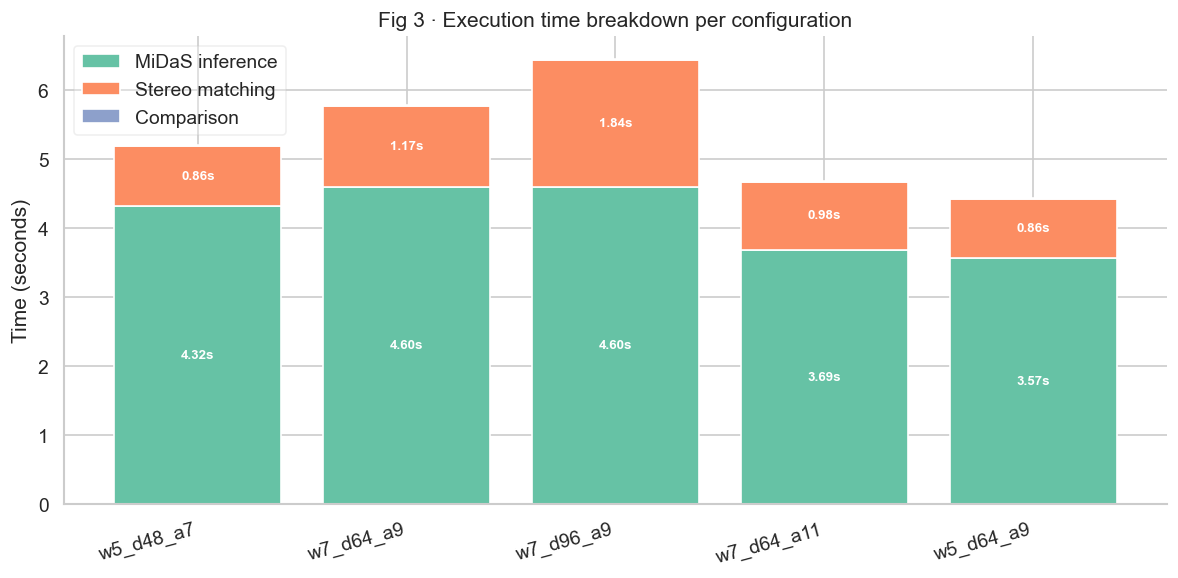

In [7]:
# ── 1-D · Timing breakdown stacked bar ───────────────────────────────────────
time_cols = ['avg_time_midas_s', 'avg_time_stereo_s', 'avg_time_compare_s']
time_labels = ['MiDaS inference', 'Stereo matching', 'Comparison']

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(s1_summary))
for col, label, color in zip(time_cols, time_labels, PALETTE):
    vals = s1_summary[col].values
    ax.bar(s1_summary['config'], vals, bottom=bottom, label=label, color=color)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(xi, b + v/2, f'{v:.2f}s', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Time (seconds)')
ax.set_title('Fig 3 · Execution time breakdown per configuration')
ax.set_xticklabels(s1_summary['config'], rotation=15, ha='right')
ax.legend(loc='upper left', framealpha=0.3)
plt.tight_layout()
plt.show()

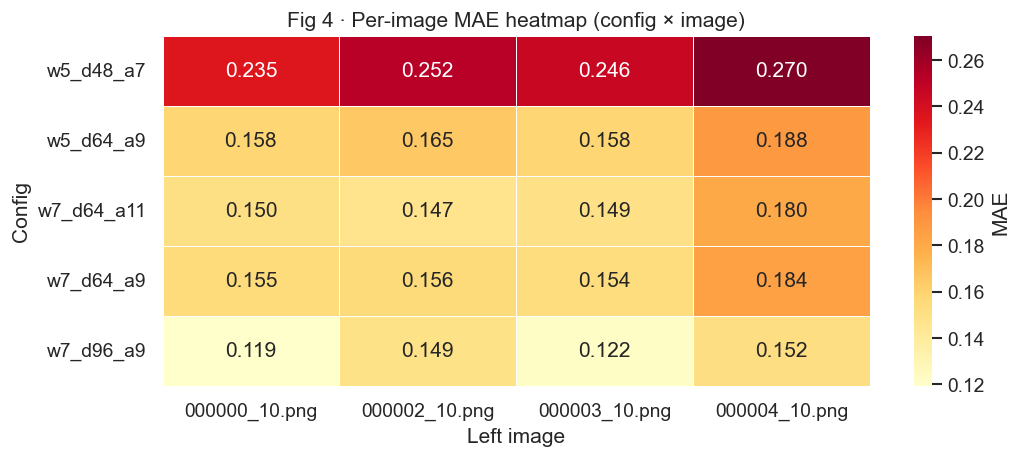

In [8]:
# ── 1-E · Per-image MAE heatmap ───────────────────────────────────────────────
pivot_mae = s1_metrics.pivot_table(
    index='config', columns='left_image', values='mae', aggfunc='mean'
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_mae, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('Fig 4 · Per-image MAE heatmap (config × image)')
ax.set_xlabel('Left image')
ax.set_ylabel('Config')
plt.tight_layout()
plt.show()

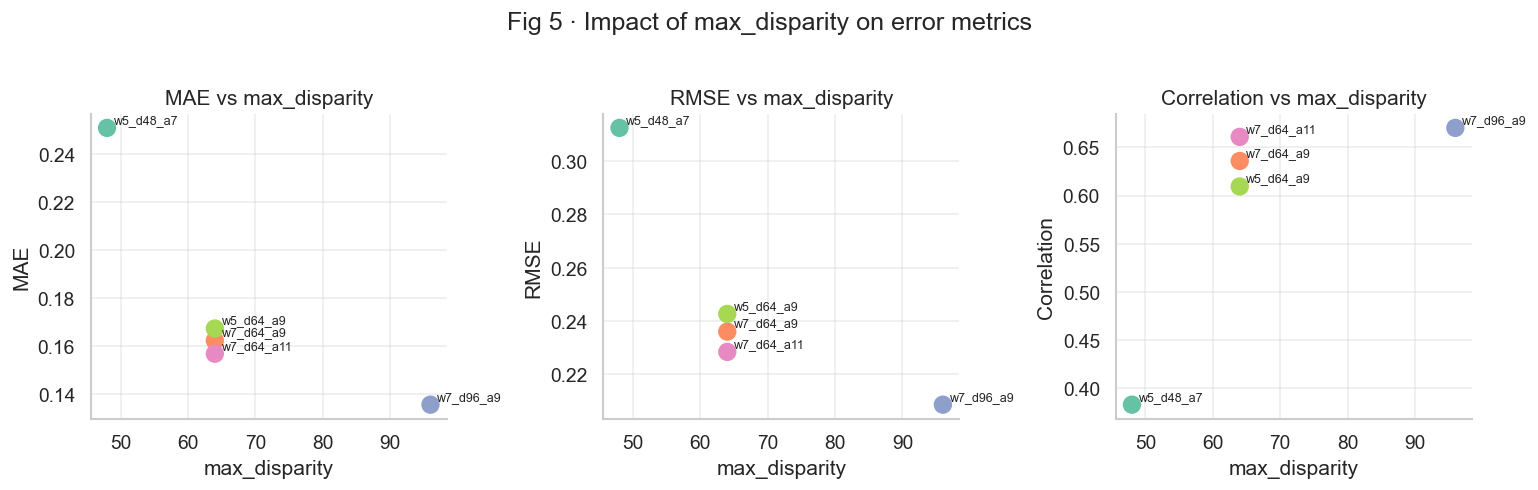

In [9]:
# ── 1-F · Effect of max_disparity on metrics ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics_to_plot = ['avg_mae', 'avg_rmse', 'avg_corr']
ylabels = ['MAE', 'RMSE', 'Correlation']

for ax, metric, ylabel in zip(axes, metrics_to_plot, ylabels):
    ax.scatter(s1_summary['max_disparity'], s1_summary[metric],
               s=100, c=PALETTE[:len(s1_summary)], zorder=3)
    for _, row in s1_summary.iterrows():
        ax.annotate(row['config'], (row['max_disparity'], row[metric]),
                    textcoords='offset points', xytext=(4, 3), fontsize=7.5)
    ax.set_xlabel('max_disparity')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs max_disparity')
    ax.grid(True, alpha=0.35)

fig.suptitle('Fig 5 · Impact of max_disparity on error metrics', y=1.02)
plt.tight_layout()
plt.show()

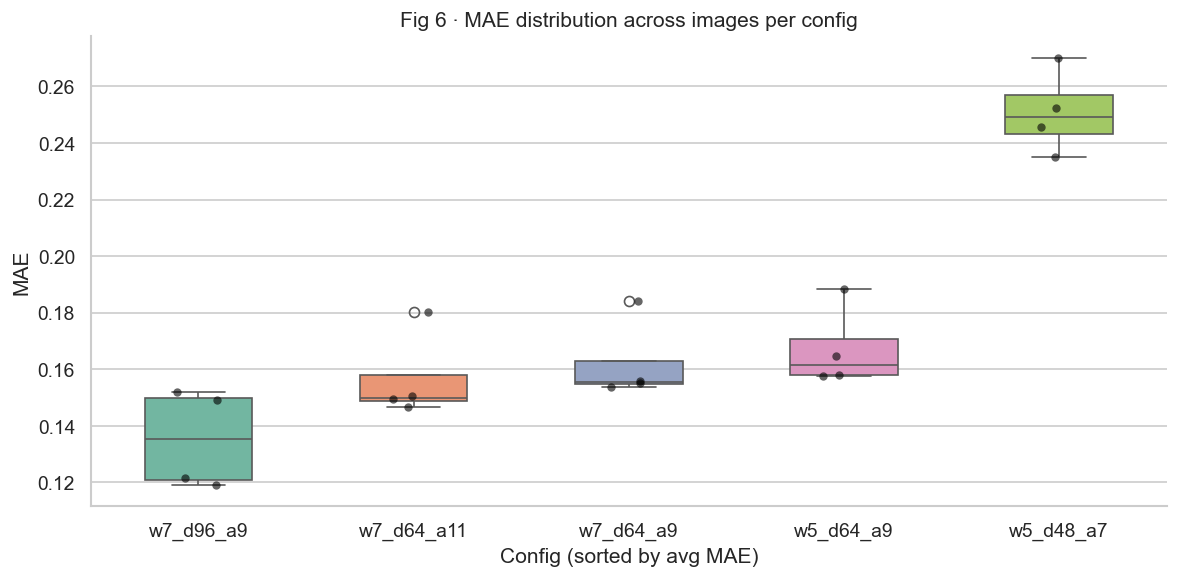

In [10]:
# ── 1-G · Box plots: MAE distribution across images per config ───────────────
fig, ax = plt.subplots(figsize=(10, 5))
config_order = s1_summary.sort_values('avg_mae')['config'].tolist()
sns.boxplot(data=s1_metrics, x='config', y='mae', order=config_order,
            palette='Set2', ax=ax, width=0.5)
sns.stripplot(data=s1_metrics, x='config', y='mae', order=config_order,
              color='black', alpha=0.6, size=5, ax=ax)
ax.set_xlabel('Config (sorted by avg MAE)')
ax.set_ylabel('MAE')
ax.set_title('Fig 6 · MAE distribution across images per config')
plt.tight_layout()
plt.show()

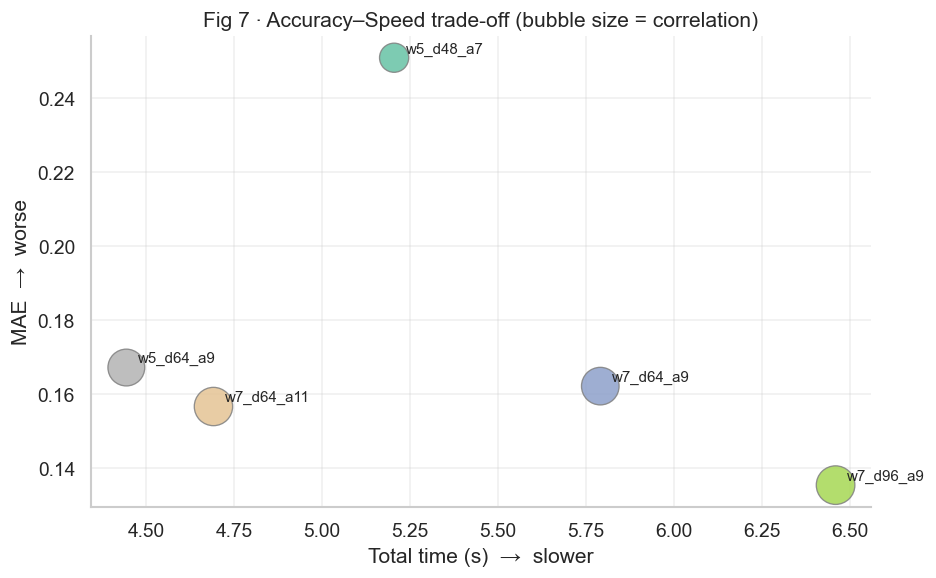

Ideal config: bottom-left (low MAE, fast). Larger bubble = higher correlation.


In [11]:
# ── 1-H · Accuracy vs Speed Pareto front ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    s1_summary['avg_time_total_s'],
    s1_summary['avg_mae'],
    s=s1_summary['avg_corr'] * 800,  # bubble = correlation
    c=range(len(s1_summary)), cmap='Set2', alpha=0.85, edgecolors='gray', linewidth=0.8
)
for _, row in s1_summary.iterrows():
    ax.annotate(row['config'], (row['avg_time_total_s'], row['avg_mae']),
                textcoords='offset points', xytext=(7, 3), fontsize=9)

ax.set_xlabel('Total time (s)  →  slower')
ax.set_ylabel('MAE  →  worse')
ax.set_title('Fig 7 · Accuracy–Speed trade-off (bubble size = correlation)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Ideal config: bottom-left (low MAE, fast). Larger bubble = higher correlation.')

In [12]:
# ── 1-I · Key findings ───────────────────────────────────────────────────────
best_mae  = s1_summary.loc[s1_summary['avg_mae'].idxmin()]
best_corr = s1_summary.loc[s1_summary['avg_corr'].idxmax()]
fastest   = s1_summary.loc[s1_summary['avg_time_total_s'].idxmin()]

print('=' * 55)
print('SUBTASK 1 · KEY FINDINGS')
print('=' * 55)
print(f"Best MAE        : {best_mae['config']}  (MAE={best_mae['avg_mae']:.4f})")
print(f"Best Correlation: {best_corr['config']}  (corr={best_corr['avg_corr']:.4f})")
print(f"Fastest         : {fastest['config']}  ({fastest['avg_time_total_s']:.3f} s total)")
print()
print('Stereo matching dominates run time; MiDaS is the second bottleneck.')
print('Higher max_disparity improves MAE/RMSE but increases stereo time.')
print('w7_d96_a9 achieves the best accuracy but at ~2× the cost of w5_d64_a9.')

SUBTASK 1 · KEY FINDINGS
Best MAE        : w7_d96_a9  (MAE=0.1355)
Best Correlation: w7_d96_a9  (corr=0.6704)
Fastest         : w5_d64_a9  (4.444 s total)

Stereo matching dominates run time; MiDaS is the second bottleneck.
Higher max_disparity improves MAE/RMSE but increases stereo time.
w7_d96_a9 achieves the best accuracy but at ~2× the cost of w5_d64_a9.


---
## Part 2 · Hyperparameter Sweep — YOLO + MiDaS Detection

Four configurations are tested across four images:  
`base`, `low_thresh`, `high_thresh`, `tight_range`.

**Key metrics**: detections, mean/median distance, timing breakdown.

In [13]:
# ── 2-A · Summary table ──────────────────────────────────────────────────────
s2_display = s2_summary[[
    'config', 'score_thresh', 'near_m', 'far_m',
    'avg_detections', 'avg_valid', 'avg_frac_valid',
    'avg_mean_distance_m', 'avg_median_distance_m', 'avg_time_total_s'
]]
styled2 = (
    s2_display.style
    .format({
        'score_thresh': '{:.2f}', 'near_m': '{:.1f}', 'far_m': '{:.1f}',
        'avg_detections': '{:.2f}', 'avg_valid': '{:.2f}',
        'avg_frac_valid': '{:.1%}',
        'avg_mean_distance_m': '{:.2f} m', 'avg_median_distance_m': '{:.2f} m',
        'avg_time_total_s': '{:.3f} s'
    })
    .background_gradient(subset=['avg_detections'], cmap='Blues')
    .background_gradient(subset=['avg_mean_distance_m'], cmap='Purples')
    .background_gradient(subset=['avg_time_total_s'], cmap='Oranges')
    .set_caption('Table 2 · Hyperparameter summary (YOLO + MiDaS)')
)
display(styled2)

,config,score_thresh,near_m,far_m,avg_detections,avg_valid,avg_frac_valid,avg_mean_distance_m,avg_median_distance_m,avg_time_total_s
0,base,0.70,1.0,50.0,5.75,5.75,100.0%,32.91 m,35.59 m,3.527 s
1,low_thresh,0.50,1.0,50.0,8.00,8.00,100.0%,33.63 m,36.12 m,3.510 s
2,high_thresh,0.85,1.0,50.0,2.50,2.50,100.0%,27.84 m,28.55 m,3.505 s
3,tight_range,0.70,0.5,30.0,5.75,5.75,100.0%,19.71 m,21.32 m,3.503 s


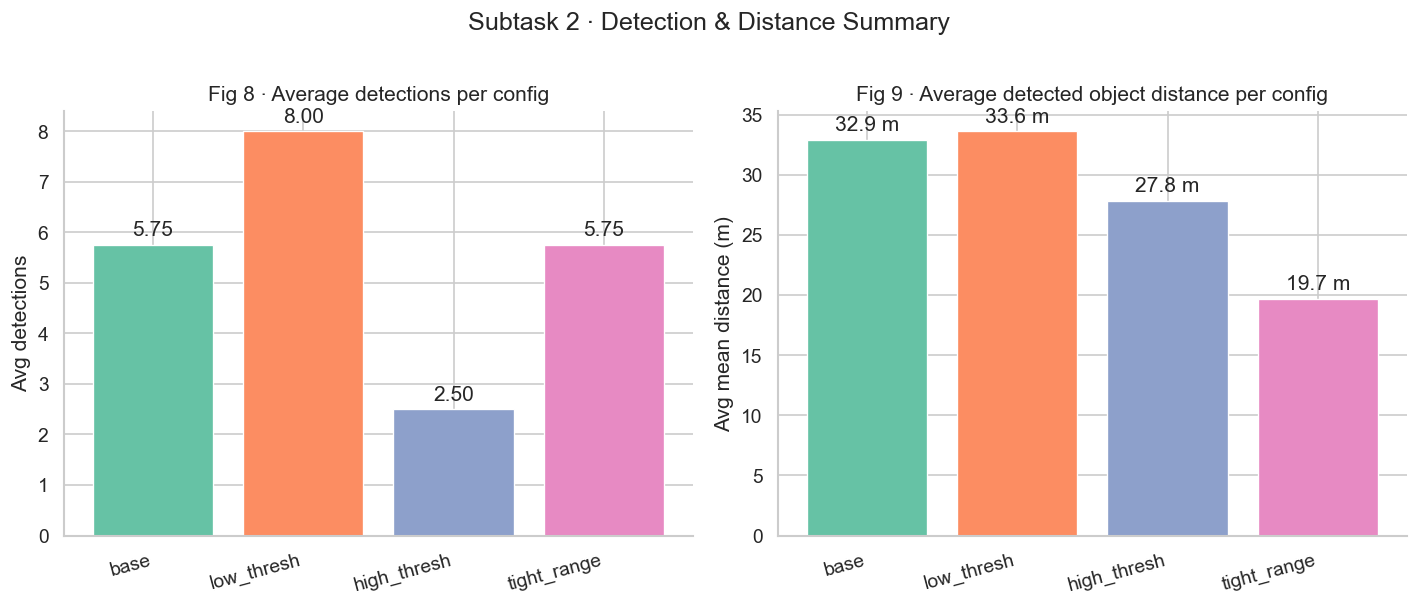

In [14]:
# ── 2-B · Detections vs distance per config ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar: average detections
ax = axes[0]
bars = ax.bar(s2_summary['config'], s2_summary['avg_detections'],
              color=PALETTE[:4], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel('Avg detections')
ax.set_title('Fig 8 · Average detections per config')
ax.set_xticklabels(s2_summary['config'], rotation=15, ha='right')

# Bar: mean distance
ax = axes[1]
bars = ax.bar(s2_summary['config'], s2_summary['avg_mean_distance_m'],
              color=PALETTE[:4], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f m', padding=3)
ax.set_ylabel('Avg mean distance (m)')
ax.set_title('Fig 9 · Average detected object distance per config')
ax.set_xticklabels(s2_summary['config'], rotation=15, ha='right')

plt.suptitle('Subtask 2 · Detection & Distance Summary', y=1.01)
plt.tight_layout()
plt.show()

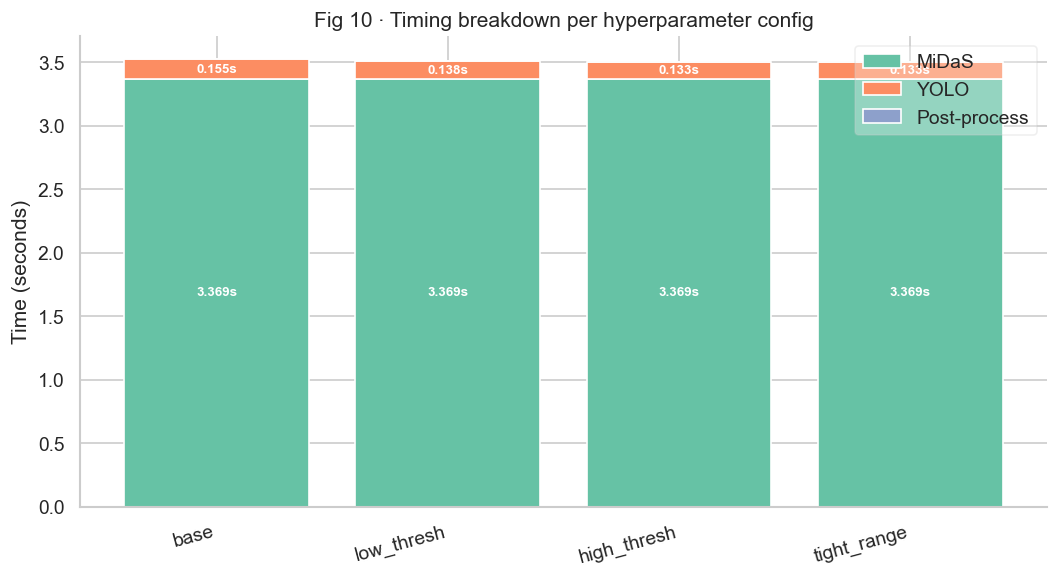

MiDaS dominates time in all configs. base is slowest due to initial YOLO warm-up.


In [15]:
# ── 2-C · Timing breakdown stacked bar ───────────────────────────────────────
time_cols2  = ['avg_time_midas_s', 'avg_time_yolo_s', 'avg_time_post_s']
time_labels2 = ['MiDaS', 'YOLO', 'Post-process']

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(s2_summary))
for col, label, color in zip(time_cols2, time_labels2, PALETTE):
    vals = s2_summary[col].values
    ax.bar(s2_summary['config'], vals, bottom=bottom, label=label, color=color)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.005:
            ax.text(xi, b + v/2, f'{v:.3f}s', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Time (seconds)')
ax.set_title('Fig 10 · Timing breakdown per hyperparameter config')
ax.set_xticklabels(s2_summary['config'], rotation=15, ha='right')
ax.legend(loc='upper right', framealpha=0.3)
plt.tight_layout()
plt.show()
print('MiDaS dominates time in all configs. base is slowest due to initial YOLO warm-up.')

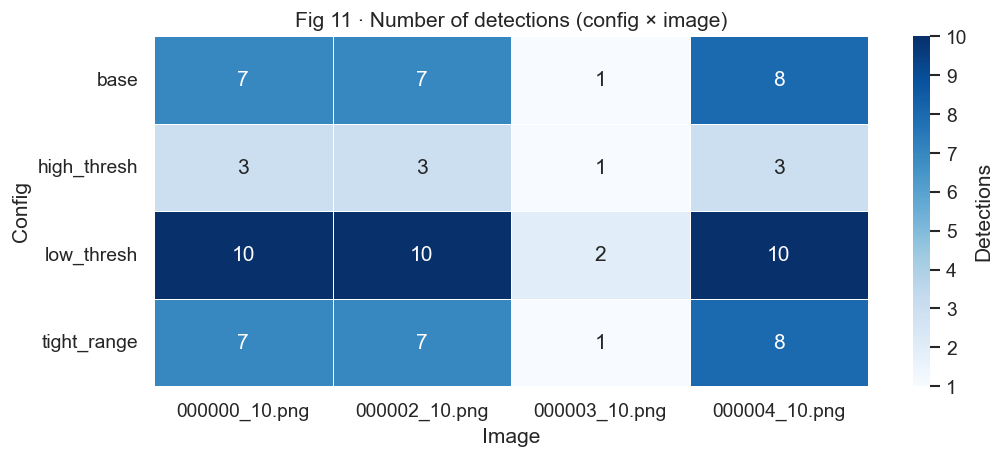

In [16]:
# ── 2-D · Per-image detections heatmap ───────────────────────────────────────
pivot_det = s2_metrics.pivot_table(
    index='config', columns='image', values='num_detections', aggfunc='sum'
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_det, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Detections'})
ax.set_title('Fig 11 · Number of detections (config × image)')
ax.set_xlabel('Image')
ax.set_ylabel('Config')
plt.tight_layout()
plt.show()

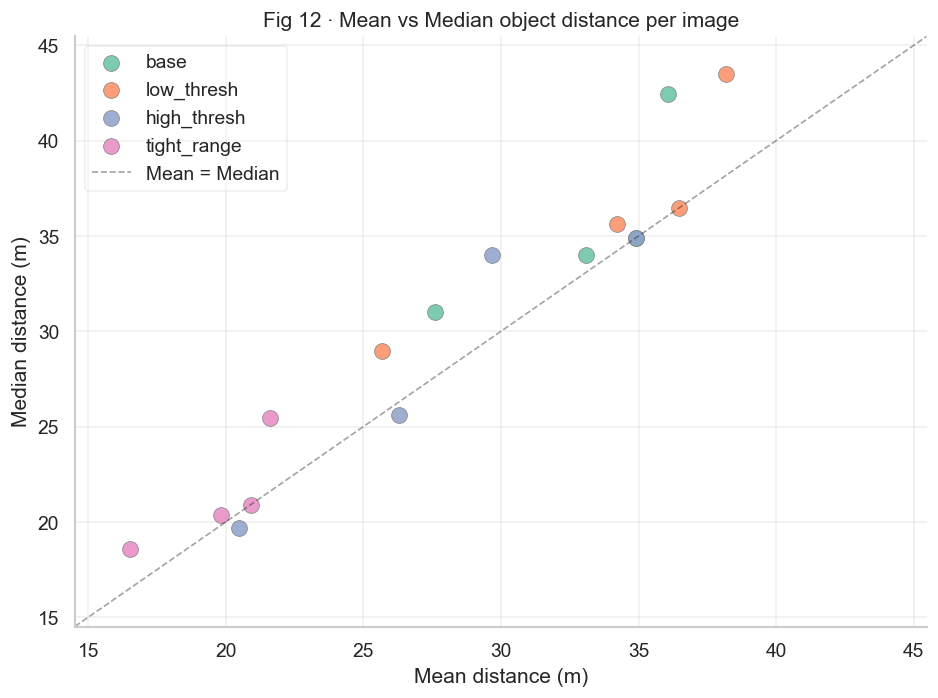

Points above the dashed line → skewed by close objects; below → skewed by distant ones.


In [17]:
# ── 2-E · Mean vs Median distance scatter (per image, per config) ─────────────
fig, ax = plt.subplots(figsize=(8, 6))
config_list = s2_metrics['config'].unique()
for i, cfg in enumerate(config_list):
    sub = s2_metrics[s2_metrics['config'] == cfg]
    ax.scatter(sub['mean_distance_m'], sub['median_distance_m'],
               label=cfg, s=90, color=PALETTE[i], alpha=0.85, edgecolors='gray', linewidth=0.5)

lims = [s2_metrics[['mean_distance_m','median_distance_m']].min().min() - 2,
        s2_metrics[['mean_distance_m','median_distance_m']].max().max() + 2]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='Mean = Median')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Mean distance (m)')
ax.set_ylabel('Median distance (m)')
ax.set_title('Fig 12 · Mean vs Median object distance per image')
ax.legend(framealpha=0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Points above the dashed line → skewed by close objects; below → skewed by distant ones.')

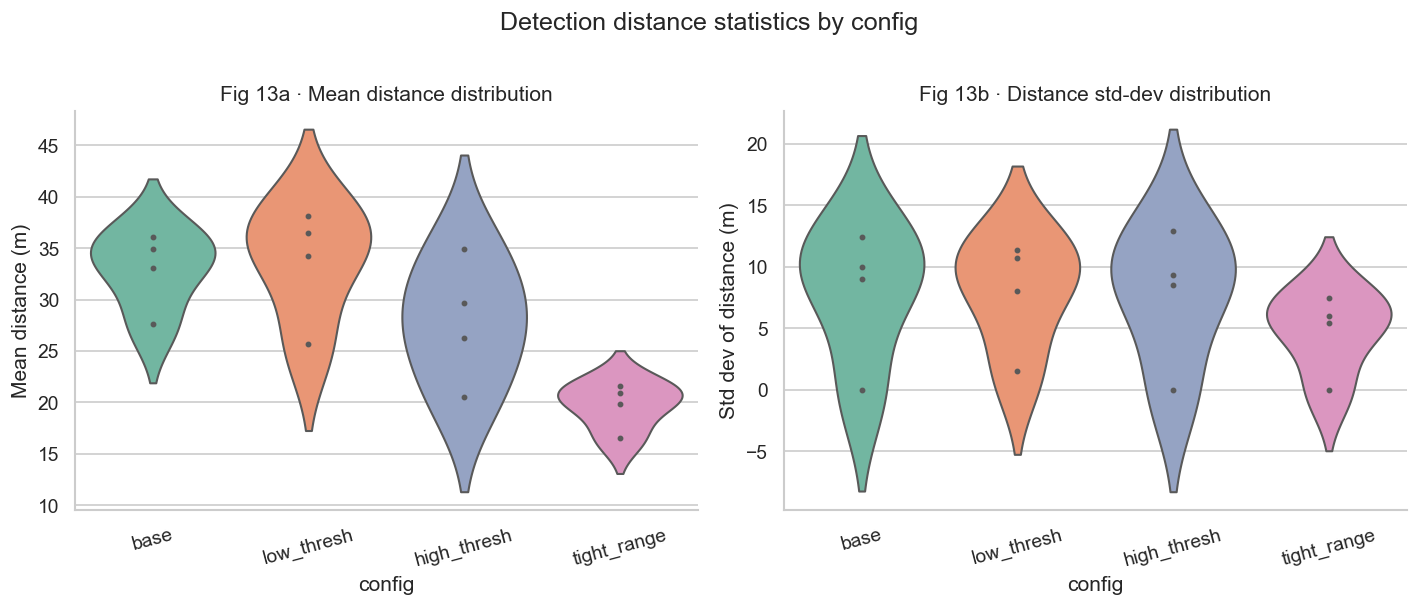

In [18]:
# ── 2-F · Distance range violin per config ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=s2_metrics, x='config', y='mean_distance_m',
               palette='Set2', inner='point', ax=axes[0])
axes[0].set_title('Fig 13a · Mean distance distribution')
axes[0].set_ylabel('Mean distance (m)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

sns.violinplot(data=s2_metrics, x='config', y='std_distance_m',
               palette='Set2', inner='point', ax=axes[1])
axes[1].set_title('Fig 13b · Distance std-dev distribution')
axes[1].set_ylabel('Std dev of distance (m)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.suptitle('Detection distance statistics by config', y=1.01)
plt.tight_layout()
plt.show()

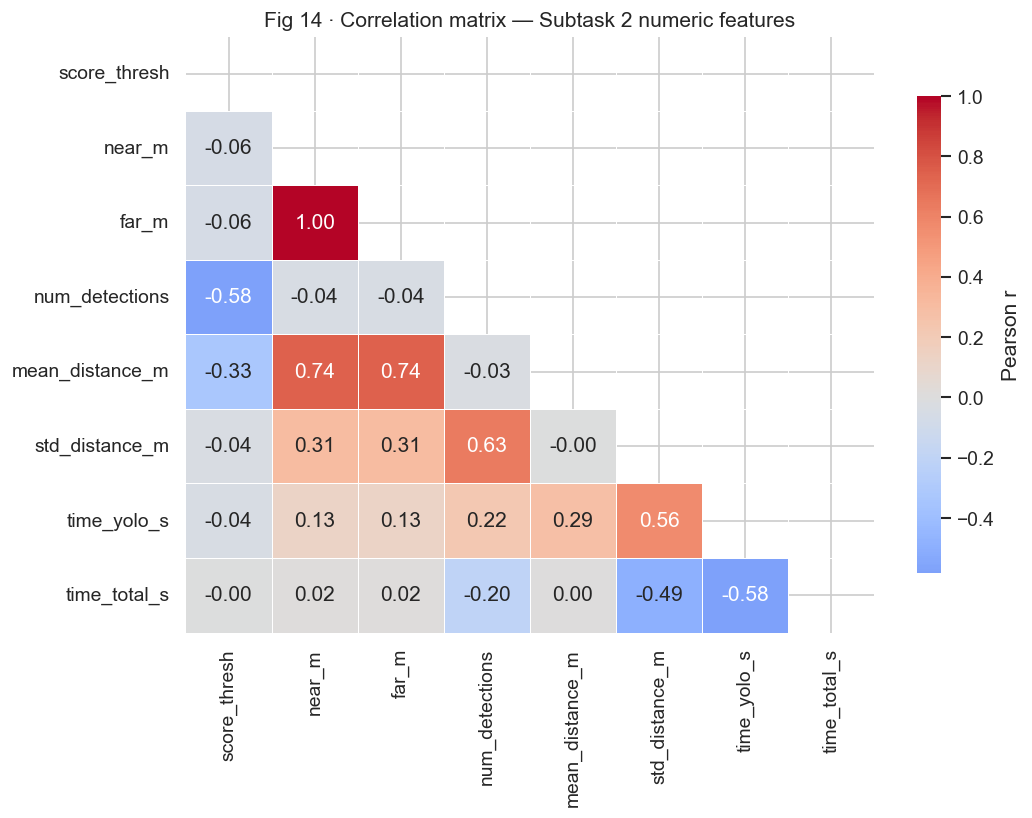

In [19]:
# ── 2-G · Correlation matrix (numeric columns, subtask 2) ────────────────────
num_cols = ['score_thresh', 'near_m', 'far_m', 'num_detections',
            'mean_distance_m', 'std_distance_m', 'time_yolo_s', 'time_total_s']
corr = s2_metrics[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Fig 14 · Correlation matrix — Subtask 2 numeric features')
plt.tight_layout()
plt.show()

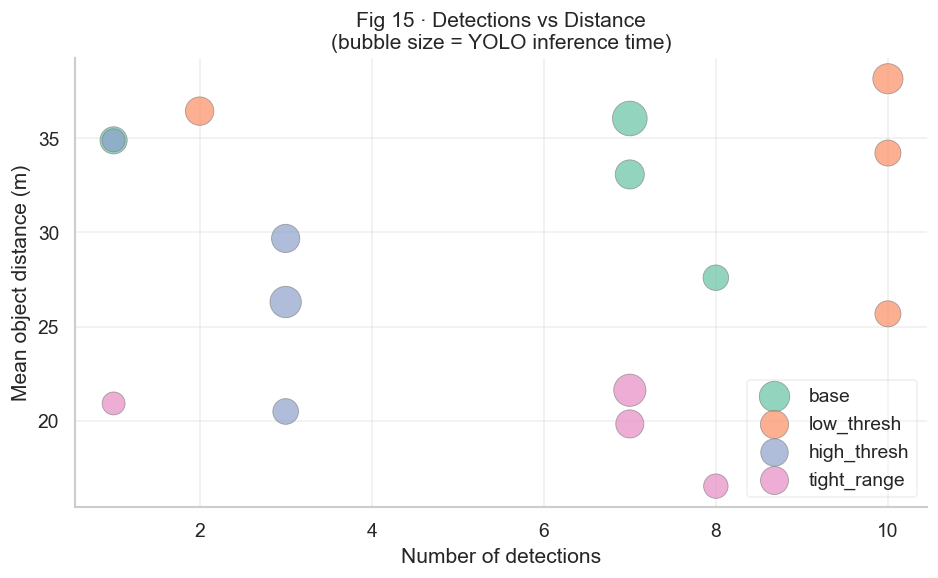

In [24]:
# ── 2-H · Detections vs mean distance (bubble = YOLO time) ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for i, cfg in enumerate(config_list):
    sub = s2_metrics[s2_metrics['config'] == cfg]
    ax.scatter(
        sub['num_detections'], sub['mean_distance_m'],
        s=sub['time_yolo_s'] * 2000,
        color=PALETTE[i], alpha=0.7, label=cfg,
        edgecolors='gray', linewidth=0.5
    )

ax.set_xlabel('Number of detections')
ax.set_ylabel('Mean object distance (m)')
ax.set_title('Fig 15 · Detections vs Distance\n(bubble size = YOLO inference time)')
ax.legend(framealpha=0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# ── 2-I · Key findings ───────────────────────────────────────────────────────
most_det  = s2_summary.loc[s2_summary['avg_detections'].idxmax()]
closest   = s2_summary.loc[s2_summary['avg_mean_distance_m'].idxmin()]
fastest2  = s2_summary.loc[s2_summary['avg_time_total_s'].idxmin()]

print('=' * 55)
print('SUBTASK 2 · KEY FINDINGS')
print('=' * 55)
print(f"Most detections : {most_det['config']}  ({most_det['avg_detections']:.2f} avg)")
print(f"Shortest range  : {closest['config']}   ({closest['avg_mean_distance_m']:.2f} m avg)")
print(f"Fastest         : {fastest2['config']}  ({fastest2['avg_time_total_s']:.3f} s total)")
print()
print('MiDaS depth inference is the dominant cost (~93% of total time).')
print('low_thresh detects the most objects but may include false positives.')
print('tight_range halves effective distance range, reducing clutter.')
print('high_thresh gives fewest but most confident detections.')

SUBTASK 2 · KEY FINDINGS
Most detections : low_thresh  (8.00 avg)
Shortest range  : tight_range   (19.71 m avg)
Fastest         : tight_range  (3.503 s total)

MiDaS depth inference is the dominant cost (~93% of total time).
low_thresh detects the most objects but may include false positives.
tight_range halves effective distance range, reducing clutter.
high_thresh gives fewest but most confident detections.


---
## Cross-task summary

| Aspect | Subtask 1 (stereo matching) | Subtask 2 (YOLO+depth) |
|---|---|---|
| **Best accuracy config** | `w7_d96_a9` | `high_thresh` (fewest false positives) |
| **Fastest config** | `w5_d64_a9` | `tight_range` |
| **Main bottleneck** | Stereo matching | MiDaS inference |
| **Recommended balanced** | `w7_d64_a9` | `base` |

MiDaS is the shared expensive component; caching its output (as done in Subtask 2) eliminates repeated inference cost and is highly recommended for any multi-config sweep.